## Chapter 2: Fourier and Wavelet Transforms

### Section 2.1: Fourier Series and Fourier Transforms

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
# Define the domain

dx = 0.001
L = np.pi
x = L * np.arange(-1 + dx, 1 + dx, dx)
n = len(x)
nquart = int(np.floor(n/4))

In [48]:
print(dx)

0.001


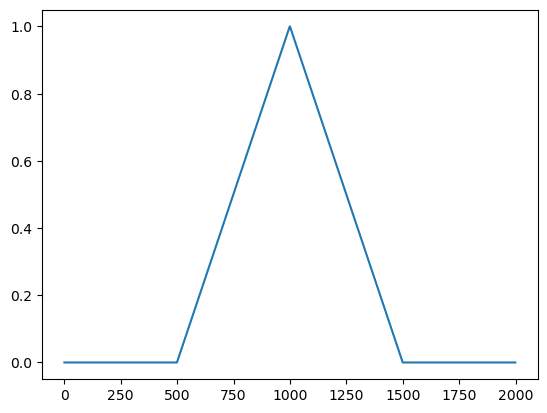

In [49]:
# Define hat function

f = np.zeros_like(x)
f[nquart:2*nquart] = (4/n) * np.arange(1, nquart + 1)
f[2 * nquart:3*nquart] = np.ones(nquart) - (4/n) * np.arange(0, nquart)

plt.plot(f)

#This is our hat function

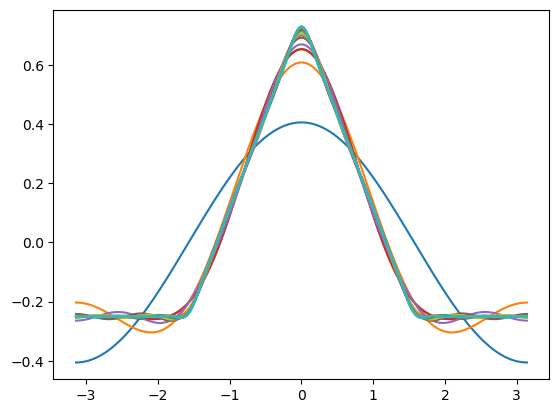

In [50]:
# Compute Fourier series

A0 = np.sum(f * np.ones_like(x)) * dx
fFS = A0/2

A = np.zeros(20)
B = np.zeros(20)

fFS = 0

for k in range(20):
    A[k] = np.sum(f * np.cos(np.pi*(k+1) * x/L)) * dx  # Inner product
    B[k] = np.sum(f * np.sin(np.pi*(k+1) * x/L)) * dx 
    fFS = fFS + A[k] * np.cos((k+1) * np.pi * x/L) + B[k] * np.sin((k+1) * np.pi * x/L)
    plt.plot(x, fFS, '-')

### Section 2.2: Discrete Fourier Transform and Fast Fourier Transform

In [51]:
#Generate discrete Fourier transform matrix
# It's important to note that DFT is not used often in the computational world, since FFT has superior scaling --> O(nlog(n)) vs O(n^2) operations

n = 256
w = np.exp(-1j * 2 * np.pi/n) #-1j is a complex number

DFT = np.zeros((n, n), dtype=complex)

#Slow DFT
for i in range(n):
    for k in range(n):
        DFT[i, k] = w ** (i*k)

DFT = np.real(DFT)

DFT

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.99969882, 0.99879546, ..., 0.99729046, 0.99879546,
        0.99969882],
       [1.        , 0.99879546, 0.99518473, ..., 0.98917651, 0.99518473,
        0.99879546],
       ...,
       [1.        , 0.99729046, 0.98917651, ..., 0.97570213, 0.98917651,
        0.99729046],
       [1.        , 0.99879546, 0.99518473, ..., 0.98917651, 0.99518473,
        0.99879546],
       [1.        , 0.99969882, 0.99879546, ..., 0.99729046, 0.99879546,
        0.99969882]], shape=(256, 256))

In [52]:
# Fast DFT

J, K = np.meshgrid(np.arange(n), np.arange(n))
DFT = np.power(w, J*K)
DFT = np.real(DFT)

DFT

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.99969882, 0.99879546, ..., 0.99729046, 0.99879546,
        0.99969882],
       [1.        , 0.99879546, 0.99518473, ..., 0.98917651, 0.99518473,
        0.99879546],
       ...,
       [1.        , 0.99729046, 0.98917651, ..., 0.97570213, 0.98917651,
        0.99729046],
       [1.        , 0.99879546, 0.99518473, ..., 0.98917651, 0.99518473,
        0.99879546],
       [1.        , 0.99969882, 0.99879546, ..., 0.99729046, 0.99879546,
        0.99969882]], shape=(256, 256))

In [53]:
fhat = np.fft.fft(f) # Fast Fourier Transform Command
f = np.fft.ifft(fhat) # Inverse fast Forier transform

In [54]:
# Fast Fourier Transform to de-noise a signal (example)

# Create a simple signal with two frequencies

dt = 0.001
t = np.arange(0, 1, dt)
f = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t)
f_clean = f
f = f + 2.5 * np.random.randn(len(t)) #Adding noise

In [55]:
# Compute the Fast Fourier Transform

n = len(t)
fhat = np.fft.fft(f, n) # Compute the FFT
PSD = fhat * np.conj(fhat) / n # Power spectrum (power per freq)

freq = (1/(dt*n)) * np.arange(n) # Create x-axis of frequencies in HZ

L = np.arange(1, np.floor(n/2), dtype = 'int') # Only plot the first half of frequencies

In [56]:
# Use the PSD to filter out noise

indices = PSD > 100 # Find all frequencies with large power
PSDclean = PSD * indices
fhat = indices * fhat # Zero out small Fourier coeffs. in Y
ffilt = np.fft.ifft(fhat) # Inverse FFT for filtered time signal

In [57]:
## Derivative using FFT (spectral derivative)

fhat = np.fft.fft(f)
kappa = (2*np.pi/L) * np.arange(-len(t)/2, len(t)/2)
kappa = np.fft.fftshift(kappa) # Reorder fft frequencies

dfhat = kappa * fhat * (1j)
dfFFT = np.real(np.fft.ifft(dfhat))

ValueError: operands could not be broadcast together with shapes (499,) (1000,) 